In [21]:
import sandbox_module
import numpy as np
import pandas as pd
# List imported from sandbox_module functions
# print(dir(sandbox_module))
np.random.seed(42)

DAG adjacency matrix:
   U  X  Y  Z
U  0  0  1  0
X  0  0  1  0
Y  0  0  0  0
Z  1  1  0  0


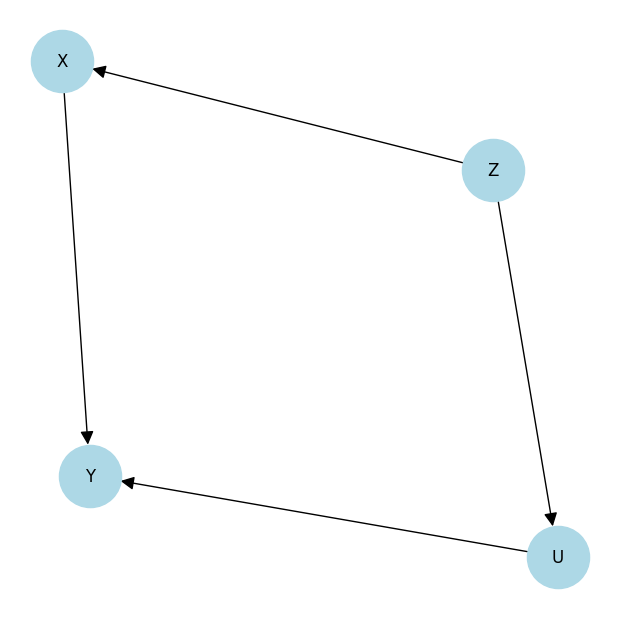

In [8]:
# Sample size

var_names = ['U', 'X', 'Y', 'Z']
adj_matrix = np.array([
    [0, 0, 1, 0],  # U → Y
    [0, 0, 1, 0],  # X → Y
    [0, 0, 0, 0],  # Y
    [1, 1, 0, 0]   # Z → U and Z → X
])

sample_size = 100
for row in adj_matrix:
    x = np.random.normal(0, 1, sample_size)
    # x  = np.random.uniform(size=sample_size) # as in the LinGAM paper
    for col in row:
        x = x + col * np.random.normal(0, 1, sample_size)



# SCM: latent ability/confounder
n = 100
U = np.random.normal(0, 1, n)
# Observed proxy for U (backdoor)
Z = U + np.random.normal(0, 0.1, n)
# Study hours X depends on confounder Z
X = 2 + 1.5 * Z + np.random.normal(0, 0.5, n)
# Exam score Y depends on X and U (true causal effect)
Y = 50 + 5*X + 3*U + np.random.normal(0, 2, n)

# Combine into a DataFrame
data_generated = pd.DataFrame({'U':U,'X': X, 'Y': Y, 'Z': Z})
data_generated.head()

adj_matrix_df = pd.DataFrame(adj_matrix, index=var_names, columns=var_names)
print("DAG adjacency matrix:")
print(adj_matrix_df)
plot_dag(adj_matrix_df, 'test.png')

In [9]:
import matplotlib.pyplot as plt
from itertools import combinations
# For all the variables draw the pairwise scatter plots

"""
pairs = list(combinations(var_names, 2))
# Plot all pairwise scatter plots from pairs
for pair in pairs:
    var1, var2 = pair
    plt.figure()
    plt.plot(data[var1], data[var2], marker="o", linestyle="", markersize=1)
    plt.xlabel(f"${var1}$")
    plt.ylabel(f"${var2}$")
    plt.title(f"Scatter plot of {var1} vs {var2}")
    plt.show()
"""


'\npairs = list(combinations(var_names, 2))\n# Plot all pairwise scatter plots from pairs\nfor pair in pairs:\n    var1, var2 = pair\n    plt.figure()\n    plt.plot(data[var1], data[var2], marker="o", linestyle="", markersize=1)\n    plt.xlabel(f"${var1}$")\n    plt.ylabel(f"${var2}$")\n    plt.title(f"Scatter plot of {var1} vs {var2}")\n    plt.show()\n'

In [10]:
 # Instantiate the DirectLiNGAM model
import lingam
model = lingam.DirectLiNGAM()

# Fit the model to the data DataFrame
# The 'data' DataFrame was generated in the previous step and contains the synthetic observational data.
model.fit(data_generated)

# Extract the learned adjacency matrix
# The adjacency_matrix_ attribute returns a numpy array. Convert it to a Pandas DataFrame.
# Create a directed graph from the adjacency matrix
G_true = nx.from_pandas_adjacency(adj_matrix_df, create_using=nx.DiGraph)
# Get a topological sort of the nodes
topological_order = list(nx.topological_sort(G_true))

learned_dag_matrix_df = pd.DataFrame(model.adjacency_matrix_, index=topological_order, columns=topological_order)

print("Learned DAG adjacency matrix using DirectLiNGAM:")
print(learned_dag_matrix_df)
print(f"Dimensions of the learned DAG matrix: {learned_dag_matrix_df.shape}")
print(f"Total number of edges in the learned DAG: {learned_dag_matrix_df.sum().sum()}")

Learned DAG adjacency matrix using DirectLiNGAM:
          Z         U    X         Y
Z  0.000000  0.582859  0.0  0.000000
U  0.000000  0.000000  0.0  0.000000
X  0.000000  5.023535  0.0  2.779433
Y  1.014112  0.000000  0.0  0.000000
Dimensions of the learned DAG matrix: (4, 4)
Total number of edges in the learned DAG: 9.399939288278429


In [11]:


import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
def plot_dag(dag_df, filename=None):
    adj_matrix = dag_df.values
    var_names = dag_df.columns.tolist()
    G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)
    mapping = {i: var_names[i] for i in range(len(var_names))}
    G = nx.relabel_nodes(G, mapping)
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', arrowsize=20)
    # plt.title("SCM Graph Structure")
    # plt.rcParams['font.family'] = 'DejaVu Serif'
    if filename:
        plt.savefig(filename, format='png', dpi=300)
    else:
        plt.show()


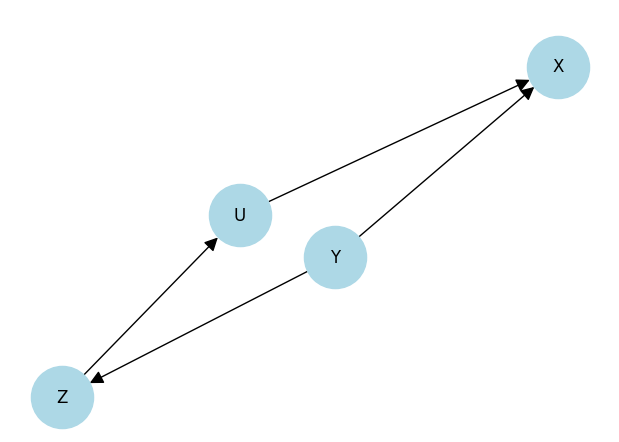

In [14]:
G = nx.from_numpy_array(model.adjacency_matrix_, create_using=nx.DiGraph)
mapping = {i: var_names[i] for i in range(len(var_names))}
#mapping = {i: name for i, name in enumerate(topological_order)}
G = nx.relabel_nodes(G, mapping)
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', arrowsize=20)
plt.title("SCM Graph Structure")
plt.show()

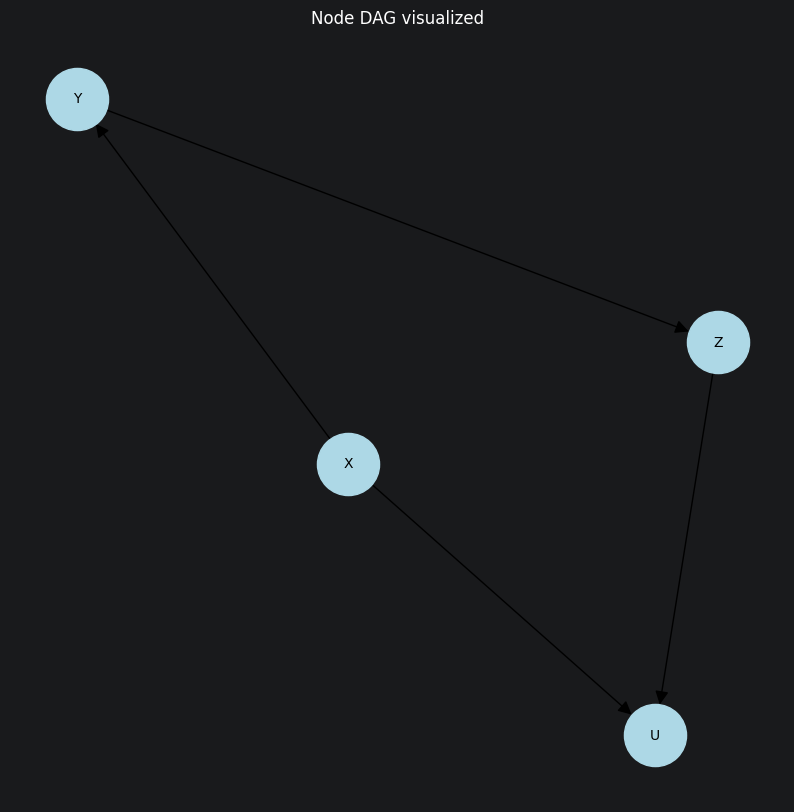

In [13]:
# Visualize the test DAG using NetworkX
viz_graph = nx.from_numpy_array(model.adjacency_matrix_, create_using=nx.DiGraph)
# Map node indices to their names
viz_mapping = {i: name for i, name in enumerate(topological_order)}
G = nx.relabel_nodes(viz_graph, viz_mapping)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)  # For consistent layout
nx.draw_networkx(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, arrowsize=20)
plt.title('Node DAG visualized')
plt.axis('off')
plt.show()